# Portfolio Project: Marketing Attribution & Campaign Analytics
## Notebook 03: Demographic & Brand Exploratory Data Analysis (EDA)

**Role:** Data Analyst  
**Prepared by:** Akshansh Vijay  
**Objective:** Evaluate marketing efficiency across demographic segments, localized languages, and brand portfolios (Nykaa, Purplle, Tira) using descriptive statistics and visual bar charts.

### 1. Load Preprocessed Clean Dataset

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Resolve path
data_dir = 'data'
if not os.path.exists(data_dir):
    data_dir = os.path.join('..', 'data')

# Load clean data
marketing = pd.read_csv(os.path.join(data_dir, 'marketing_data_cleaned.csv'))

### 2. Brand Performance Audit
We group campaign results by **Brand** to compare Revenue, ROI, CTR, Conversion Rate, CPA, and Acquisition Cost.

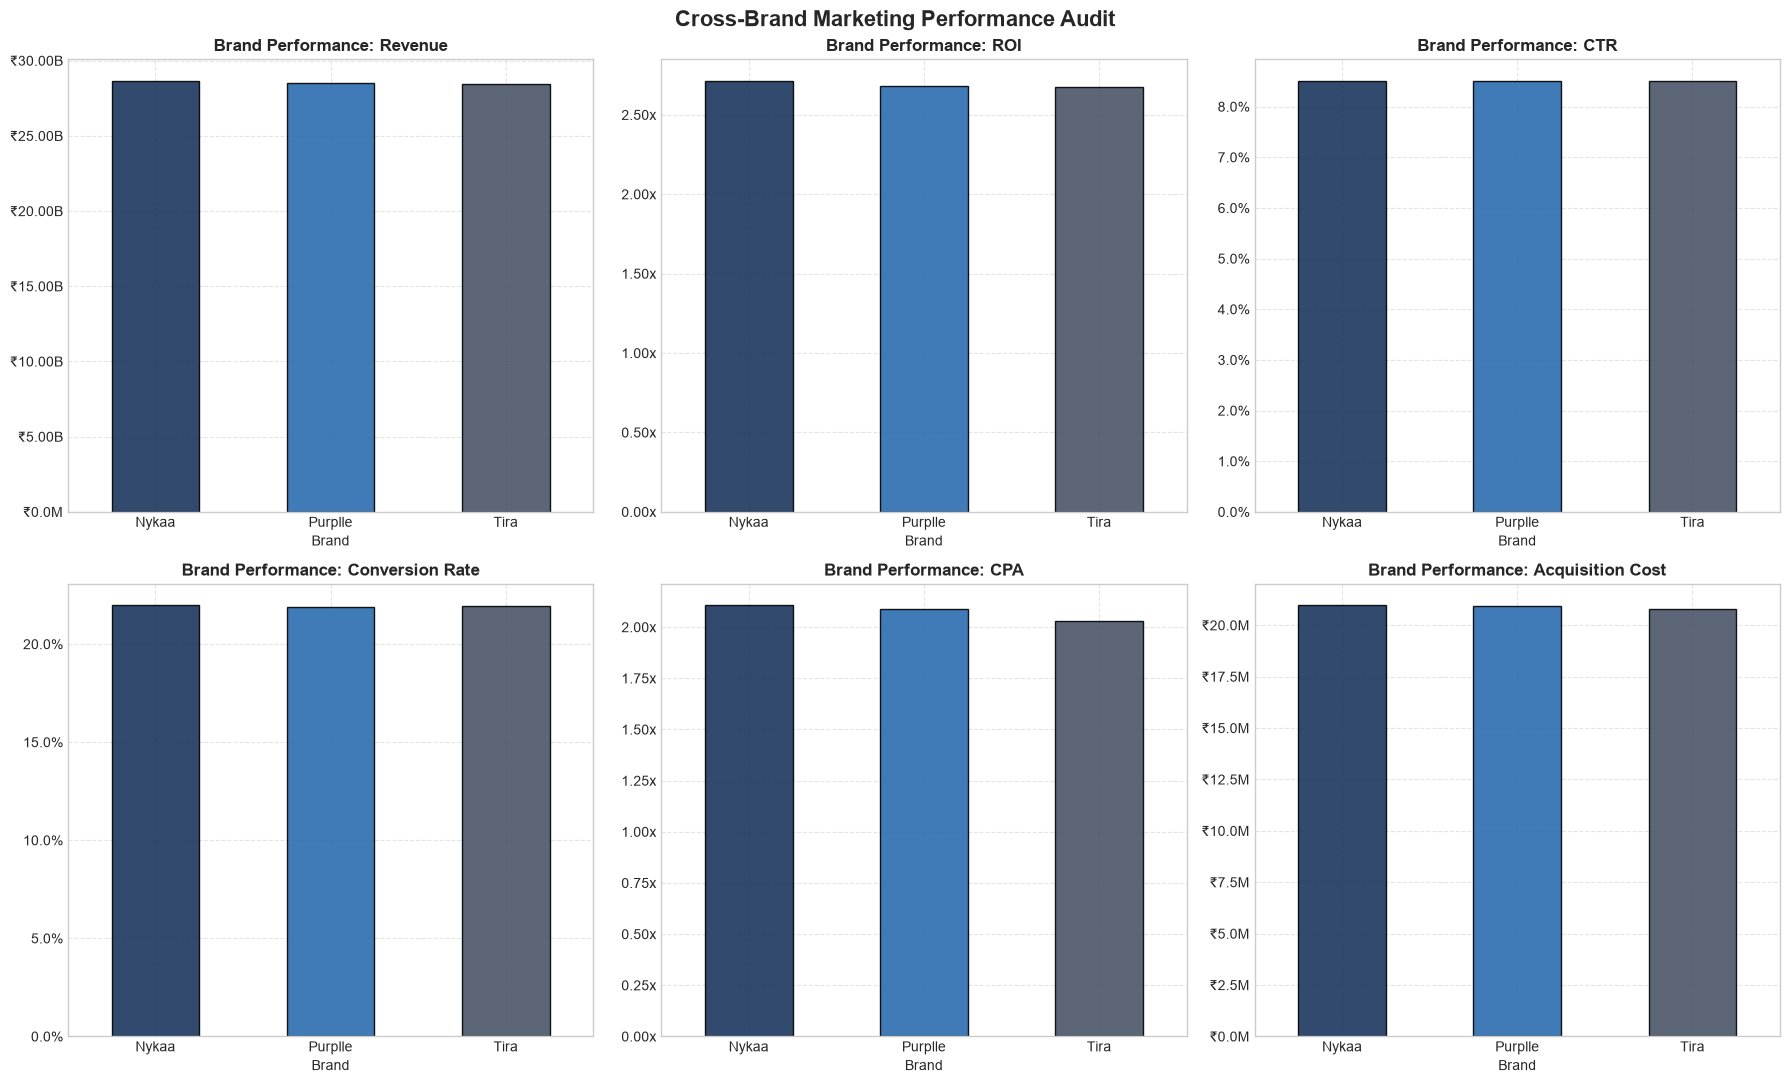

,Revenue,ROI,CTR,Conversion_Rate,CPA,Acquisition_Cost
Brand,,,,,,
Nykaa,28656364282,2.713807,8.508690,21.971554,2.106050,20963516.36
Purplle,28540346627,2.682922,8.497732,21.906797,2.090863,20925359.84
Tira,28453535162,2.674971,8.500560,21.957759,2.031649,20792977.13


In [2]:
# Group by Brand
brand_stats = marketing.groupby('Brand').agg({
    'Revenue': 'sum',
    'ROI': 'mean',
    'CTR': 'mean',
    'Conversion_Rate': 'mean',
    'CPA': 'mean',
    'Acquisition_Cost': 'sum'
})

# Plot Brand statistics
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 11), dpi=100)
axes = axes.flatten()
colors = ['#1a365d', '#2b6cb0', '#4a5568']

metrics = ['Revenue', 'ROI', 'CTR', 'Conversion_Rate', 'CPA', 'Acquisition_Cost']
for i, metric in enumerate(metrics):
    ax = axes[i]
    brand_stats[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.9)
    ax.set_title(f'Brand Performance: {metric.replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Brand', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Label formatting
    if metric in ['Revenue', 'Acquisition_Cost']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-6:.1f}M' if x < 1e9 else f'₹{x*1e-9:.2f}B')
    elif metric in ['CTR', 'Conversion_Rate']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1f}%')
    elif metric in ['CPA', 'ROI']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x:.2f}' if metric=='CPA' else f'{x:.2f}x')

plt.suptitle('Cross-Brand Marketing Performance Audit', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

brand_stats

### Brand Analysis - Business Interpretation
- **Revenue & Parity:** Nykaa leads total revenue at **₹28.66B**, followed by Purplle (**₹28.54B**) and Tira (**₹28.45B**). The tight revenue distribution shows highly competitive market saturation.
- **Acquisition Cost Efficiency:** **Tira** is the most cost-effective brand. It holds the lowest average CPA (**₹2.03**) and lowest total acquisition spend (**₹20.79M**), compared to Nykaa's average CPA of **₹2.11**.

### 3. Customer Segment Value Matrix
We evaluate demographic performance across **Customer Segments** to locate our highest-value target demographics.

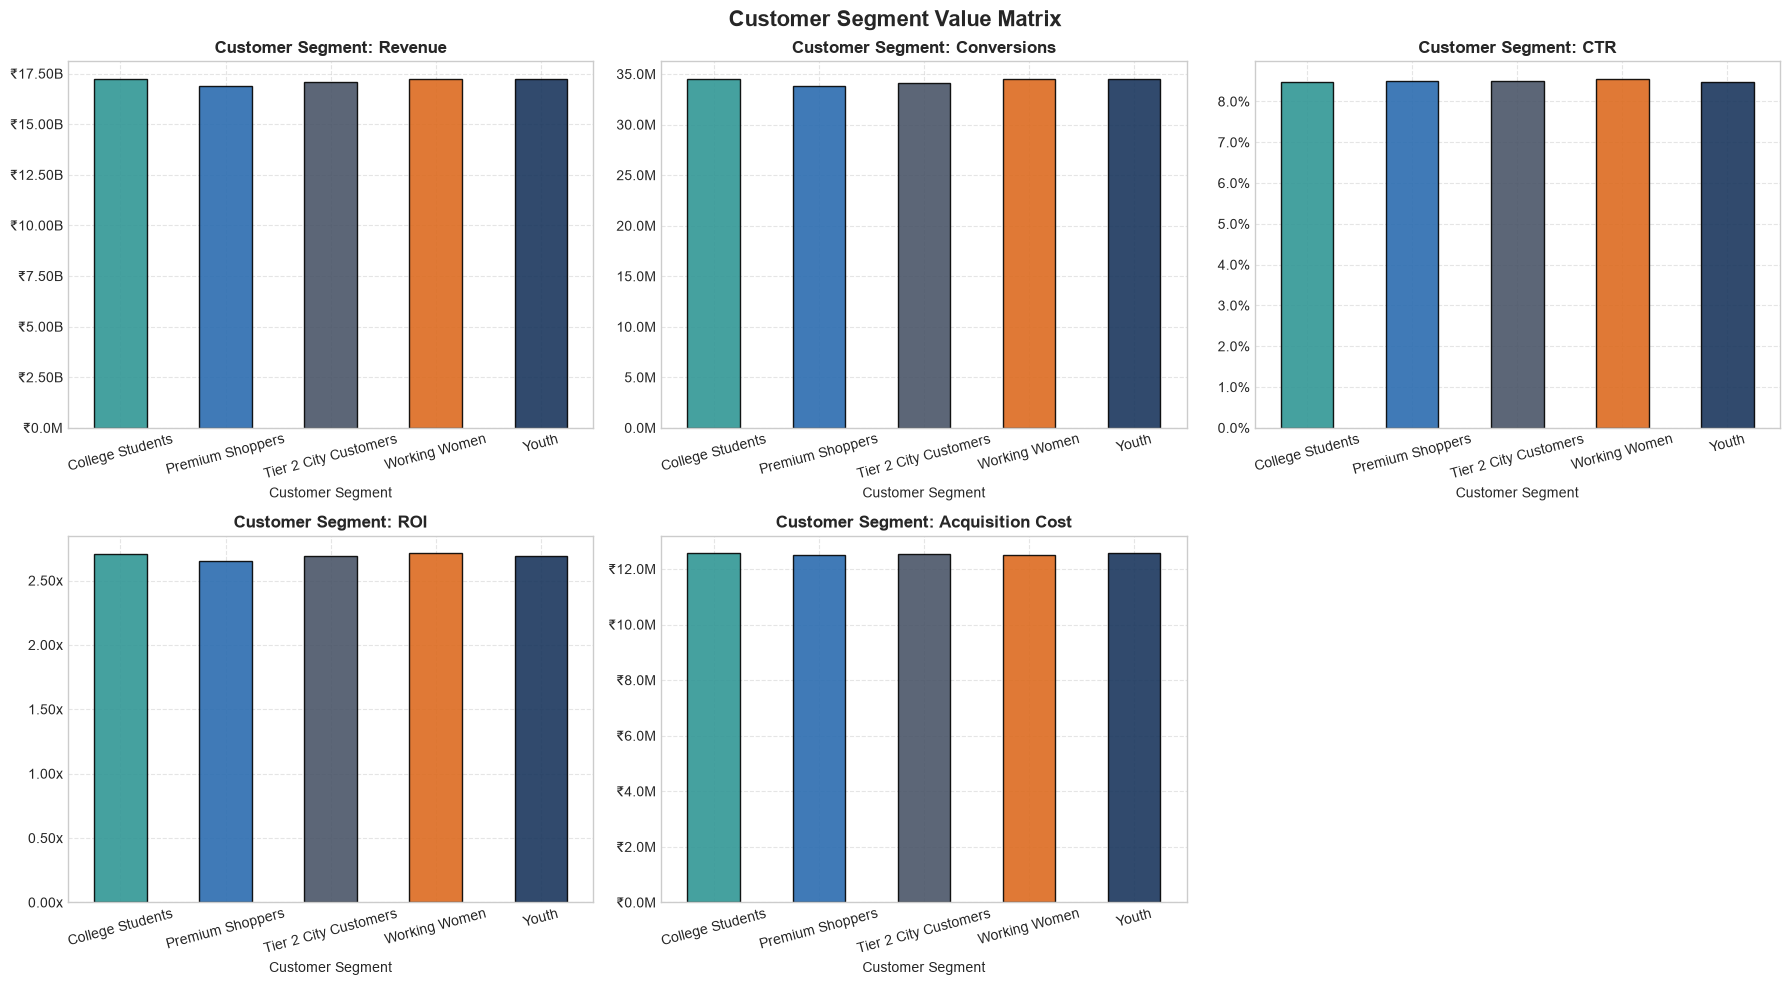

,Revenue,Conversions,CTR,ROI,Acquisition_Cost
Customer_Segment,,,,,
College Students,17243247161,34514710,8.478876,2.707245,12562498.41
Premium Shoppers,16893770924,33860455,8.496678,2.652843,12517982.64
Tier 2 City Customers,17072782747,34121667,8.504471,2.691998,12529120.28
Working Women,17215043588,34482679,8.555534,2.711046,12512946.69
Youth,17225401651,34533588,8.476235,2.689275,12559305.31


In [3]:
# Group by Segment
segment_stats = marketing.groupby('Customer_Segment').agg({
    'Revenue': 'sum',
    'Conversions': 'sum',
    'CTR': 'mean',
    'ROI': 'mean',
    'Acquisition_Cost': 'sum'
})

fig, axes = plt.subplots(2, 3, figsize=(18, 10), dpi=100)
axes = axes.flatten()
colors = ['#319795', '#2b6cb0', '#4a5568', '#dd6b20', '#1a365d']

segment_metrics = ['Revenue', 'Conversions', 'CTR', 'ROI', 'Acquisition_Cost']
for i, metric in enumerate(segment_metrics):
    ax = axes[i]
    segment_stats[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.9)
    ax.set_title(f'Customer Segment: {metric.replace("_", " ")}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Customer Segment', fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format labels
    if metric in ['Revenue', 'Acquisition_Cost']:
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-6:.1f}M' if x < 1e9 else f'₹{x*1e-9:.2f}B')
    elif metric == 'Conversions':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x*1e-6:.1f}M')
    elif metric == 'CTR':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.1f}%')
    elif metric == 'ROI':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}x')

axes[5].axis('off')
plt.suptitle('Customer Segment Value Matrix', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

segment_stats

### Customer Segment - Business Interpretation
- **Highest Value Segments:** **College Students** (₹17.24B revenue, 2.71x average ROI) and **Youth** (₹17.23B revenue, 2.69x ROI) are the most valuable buyer groups.
- **Premium Segment Diminishing Returns:** **Premium Shoppers** generate the lowest revenue (**₹16.89B**) and average ROI (**2.65x**), showing that volume-driven youth retail appeals are more effective for these brands.

### 4. Language Localization Performance
We analyze the impact of language localization (Hindi, Tamil, English, Bengali) in campaign creatives.

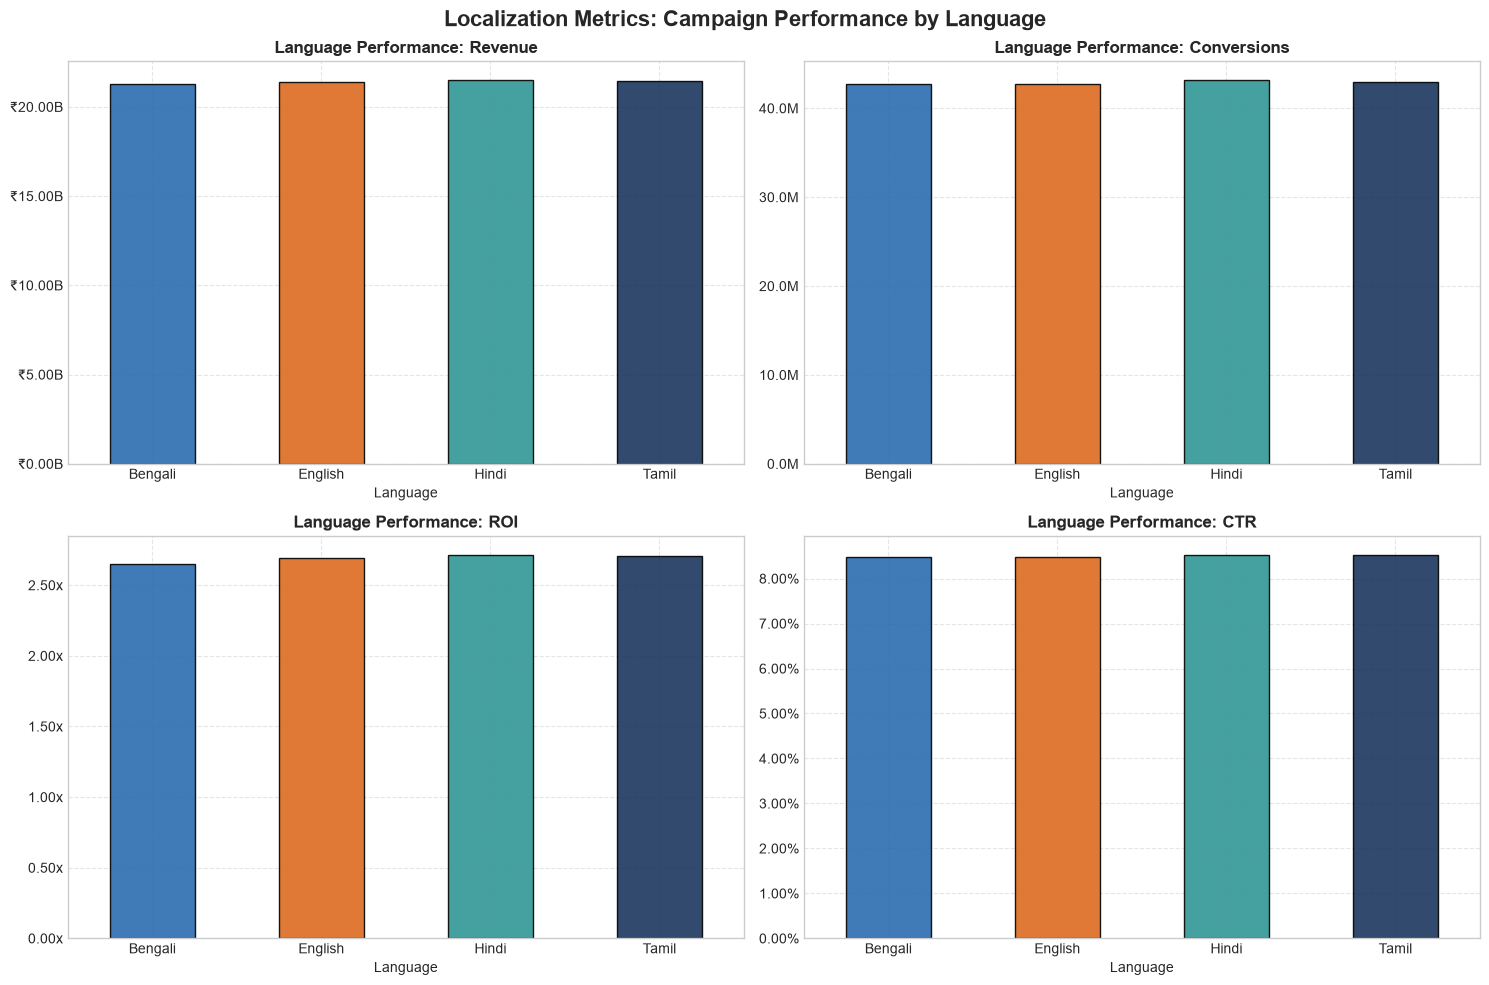

,Revenue,Conversions,ROI,CTR
Language,,,,
Bengali,21307379414,42682482,2.649262,8.478312
English,21418925404,42749621,2.693064,8.486344
Hindi,21476573089,43123269,2.713152,8.522697
Tamil,21447368164,42957727,2.706734,8.521897


In [4]:
# Group by Language
lang_stats = marketing.groupby('Language').agg({
    'Revenue': 'sum',
    'Conversions': 'sum',
    'ROI': 'mean',
    'CTR': 'mean'
})

fig, axes = plt.subplots(2, 2, figsize=(15, 10), dpi=100)
axes = axes.flatten()
colors = ['#2b6cb0', '#dd6b20', '#319795', '#1a365d']

lang_metrics = ['Revenue', 'Conversions', 'ROI', 'CTR']
for i, metric in enumerate(lang_metrics):
    ax = axes[i]
    lang_stats[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black', alpha=0.9)
    ax.set_title(f'Language Performance: {metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Language', fontsize=10)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Format labels
    if metric == 'Revenue':
        ax.yaxis.set_major_formatter(lambda x, pos: f'₹{x*1e-9:.2f}B')
    elif metric == 'Conversions':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x*1e-6:.1f}M')
    elif metric == 'CTR':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}%')
    elif metric == 'ROI':
        ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.2f}x')

plt.suptitle('Localization Metrics: Campaign Performance by Language', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

lang_stats

### Language Performance - Business Interpretation
- **Regional Market Power:** **Hindi** localized campaigns generate the highest absolute revenue (**₹21.48B**), closely followed by **Tamil** at **₹21.45B**. Both hold a high Average ROI (**2.71x**).
- **Bengali Campaigns Optimization:** **Bengali** campaigns represent the lowest total revenue (**₹21.31B**) and ROI (**2.65x**), pointing to regional ad copies that require structural adjustments to improve click-to-conversion rates.